In [2]:
from data.dataset import DiffusionDataset
import pandas as pd
import os, time 
from pathlib import Path

project_root = str(Path.cwd())
project_root


'd:\\Imperial\\IRP\\HiRISE_diffusion'

In [3]:
dr = pd.read_csv(project_root + '\\data\\files\\data_record_bin12.csv')
allowed_sets = [19645, 7292, 7293, 14774]  # observations present in data/files/npy_files_b12

dataset = DiffusionDataset(data_record=dr, data_root=project_root + "/data", sweep=False, allowed_sets=allowed_sets)

start_time = time.time()
print(f"Dataset initialisation time: {time.time() - start_time:.2f} seconds")

DiffusionDataset: 4 sets  (3 observations)
Dataset initialisation time: 0.00 seconds


In [4]:
sample = dataset[2]
print(sample.keys())

dict_keys(['ir', 'red', 'norm_stats', 'obs_id', 'set_name', 'date'])


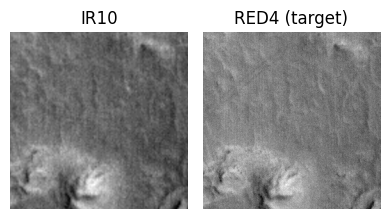

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(4, 5))

axs[0].imshow(sample['ir'][0].numpy(), cmap='gray')
axs[0].set_title("IR10")
axs[0].axis('off')
axs[1].imshow(sample['red'][0].numpy(), cmap='gray')
axs[1].set_title("RED4 (target)")
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import sys
import torch
import numpy as np
sys.path.insert(0, os.path.join(project_root, "src"))

from config import ModelConfig, InferenceConfig
from models.cm_diff_unet import UNet
from diffusion.scheduler import DDPMScheduler
from compute_prior import load_prior_stats
from inference import sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg_model = ModelConfig()
cfg_inf   = InferenceConfig()

model = UNet(
    in_channels   = cfg_model.in_channels,
    out_channels  = cfg_model.out_channels,
    base_channels = cfg_model.base_channels,
    num_res_blocks= cfg_model.num_res_blocks,
    dropout       = cfg_model.dropout,
).to(device)

ckpt = torch.load(os.path.join(project_root, "src/output/latest_bidirectional.pt"), map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded checkpoint  step={ckpt.get('step','?')}  loss={ckpt.get('loss','?'):.4f}")

scheduler = DDPMScheduler(
    timesteps  = cfg_model.timesteps,
    beta_start = cfg_model.beta_start,
    beta_end   = cfg_model.beta_end,
).to(device)

prior_red_stats = load_prior_stats(os.path.join(project_root, "src/output/prior_red.pt"), device)
prior_ir_stats = load_prior_stats(os.path.join(project_root, "src/output/prior_ir.pt"), device)

print(f"Prior RED: mu={prior_red_stats['mu'].item():.4f}  sigma={prior_red_stats['sigma'].item():.4f}")
print(f"Prior IR:  mu={prior_ir_stats['mu'].item():.4f}  sigma={prior_ir_stats['sigma'].item():.4f}")

Loaded checkpoint  step=100000  loss=0.0033
Prior RED: mu=-0.2169  sigma=0.2815
Prior IR:  mu=-0.0075  sigma=0.2249


RED histogram sum=1.000000, nonzero(>1e-6) bins=104/256
IR  histogram sum=1.000000, nonzero(>1e-6) bins=127/256


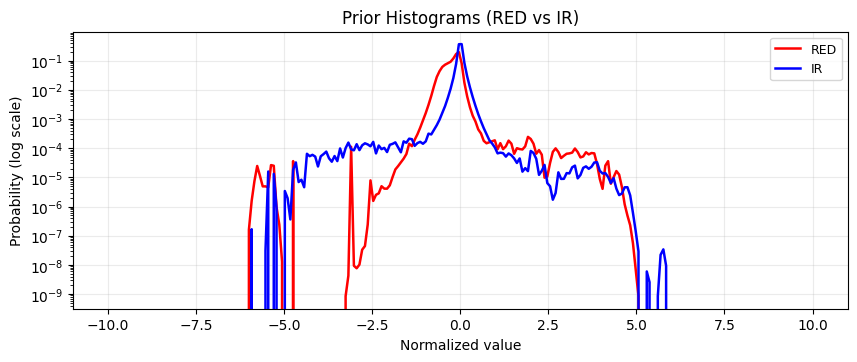

In [6]:
prior_red_hist = prior_red_stats['histogram'].cpu().numpy()
prior_ir_hist = prior_ir_stats['histogram'].cpu().numpy()

bins_red = int(prior_red_stats['bins'].item())
bins_ir  = int(prior_ir_stats['bins'].item())

x_red = np.linspace(prior_red_stats['hist_min'].item(), prior_red_stats['hist_max'].item(), bins_red)
x_ir  = np.linspace(prior_ir_stats['hist_min'].item(), prior_ir_stats['hist_max'].item(), bins_ir)

red_nz = int((prior_red_hist > 1e-6).sum())
ir_nz  = int((prior_ir_hist > 1e-6).sum())

fig, axs = plt.subplots(1, 1, figsize=(10, 3.6))

axs.plot(x_red, prior_red_hist, color='red', lw=1.8, label='RED')
axs.plot(x_ir, prior_ir_hist, color='blue', lw=1.8, label='IR')
axs.set_yscale('log')
axs.set_xlabel('Normalized value')
axs.set_ylabel('Probability (log scale)')
axs.set_title('Prior Histograms (RED vs IR)')
axs.grid(alpha=0.25)
axs.legend(loc='upper right', fontsize=9)


print(f"RED histogram sum={prior_red_hist.sum():.6f}, nonzero(>1e-6) bins={red_nz}/{bins_red}")
print(f"IR  histogram sum={prior_ir_hist.sum():.6f}, nonzero(>1e-6) bins={ir_nz}/{bins_ir}")

In [39]:
prior_red_stats.keys()

dict_keys(['mu', 'sigma', 'histogram', 'bins', 'hist_min', 'hist_max', 'min', 'max'])

In [8]:
# Pick a sample from DiffusionDataset — run both inference directions
dr = pd.read_csv(project_root + '/data/files/data_record_bin12.csv')
allowed_sets = [19645, 7292, 7293, 14774]  # observations present in data/files/npy_files_b12

dataset = DiffusionDataset(data_record=dr, data_root=project_root + "/data", sweep=False, allowed_sets=allowed_sets)

SAMPLE_IDX = 2   # change to try different samples
SEED = 42
diff_sample = dataset[SAMPLE_IDX]
print("obs={}  set={}".format(diff_sample["obs_id"], diff_sample["set_name"]))

# ── Normalization stats for denormalization ────────────────────────────────
norm_stats = diff_sample["norm_stats"]          # (2,) = [center, scale]
center = norm_stats[0].item()
scale  = norm_stats[1].item()
print("norm_stats: center={:.4f}  scale={:.4f}".format(center, scale))

use_denorm = False
def denorm(arr):
    """clamp(-10,10) then reverse: x_phys = x * scale + center"""
    if use_denorm:
        return np.clip(arr, -10, 10) * scale + center
    return arr

# ── Direction 0: IR10 -> RED4 ───────────────────────────────────────────────
ir_tensor   = diff_sample["ir"].unsqueeze(0).to(device)   # (1,1,H,W)
ir_norm     = diff_sample["ir"].squeeze().cpu().numpy() # normalized source
red_gt_norm = diff_sample["red"].squeeze().cpu().numpy()  # normalized GT

torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
cfg_dir0 = InferenceConfig(lambda_scl=100.0, lambda_ccl=100.0)
with torch.no_grad():
    pred = sample(model, scheduler, ir_tensor, direction=0,
                  prior_stats=prior_red_stats, cfg_inf=cfg_dir0, device=device)
red_pred_norm = pred.squeeze().cpu().numpy()

# Denormalize for physical-space visualization
ir_display  = denorm(ir_norm)
red_pred    = denorm(red_pred_norm)
red_gt      = denorm(red_gt_norm)
print("[IR->RED]  ir_src={:.4f}  pred={:.4f}  GT={:.4f}".format(
    ir_display.mean(), red_pred.mean(), red_gt.mean()))

# ── Direction 1: RED4 -> IR10 ───────────────────────────────────────────────
red_tensor  = diff_sample["red"].unsqueeze(0).to(device)  # (1,1,H,W)
red_norm    = diff_sample["red"].squeeze().cpu().numpy()  # normalized source
ir_gt_norm  = diff_sample["ir"].squeeze().cpu().numpy()  # normalized GT

torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
cfg_dir1 = InferenceConfig(lambda_scl=100.0, lambda_ccl=100.0)
with torch.no_grad():
    pred_ir = sample(model, scheduler, red_tensor, direction=1,
                     prior_stats=prior_ir_stats, cfg_inf=cfg_dir1, device=device)
ir_pred_norm = pred_ir.squeeze().cpu().numpy()

# Denormalize for physical-space visualization
red_display = denorm(red_norm)
ir_pred     = denorm(ir_pred_norm)
ir_gt       = denorm(ir_gt_norm)
print("[RED->IR]  red_src={:.4f}  pred={:.4f}  GT={:.4f}".format(
    red_display.mean(), ir_pred.mean(), ir_gt.mean()))


DiffusionDataset: 4 sets  (3 observations)
obs=ESP_058361_1750  set=14774
norm_stats: center=0.1770  scale=0.0500
[init] sqrt_ab_T=0.0064  mu_target=-0.2094  x_T mean≈-0.0068
  t= 900  x range=[-5.031, 4.201]
  t= 800  x range=[-4.432, 4.420]
  t= 700  x range=[-3.934, 3.962]
  t= 600  x range=[-4.361, 5.237]
  t= 500  x range=[-4.306, 3.651]
  t= 400  x range=[-3.910, 3.985]
  t= 300  x range=[-3.250, 2.834]
  t= 200  x range=[-2.452, 1.996]
  t= 100  x range=[-1.542, 1.205]
  t=   0  x range=[-0.470, 0.044]
[IR->RED]  ir_src=0.0000  pred=-0.2408  GT=-0.3386
[init] sqrt_ab_T=0.0064  mu_target=0.0000  x_T mean≈-0.0054
  t= 900  x range=[-5.027, 4.208]
  t= 800  x range=[-4.428, 4.429]
  t= 700  x range=[-3.934, 4.004]
  t= 600  x range=[-4.352, 5.309]
  t= 500  x range=[-4.197, 3.826]
  t= 400  x range=[-3.872, 4.186]
  t= 300  x range=[-3.149, 3.136]
  t= 200  x range=[-2.327, 2.254]
  t= 100  x range=[-1.307, 1.482]
  t=   0  x range=[-0.225, 0.244]
[RED->IR]  red_src=-0.3386  pred=0

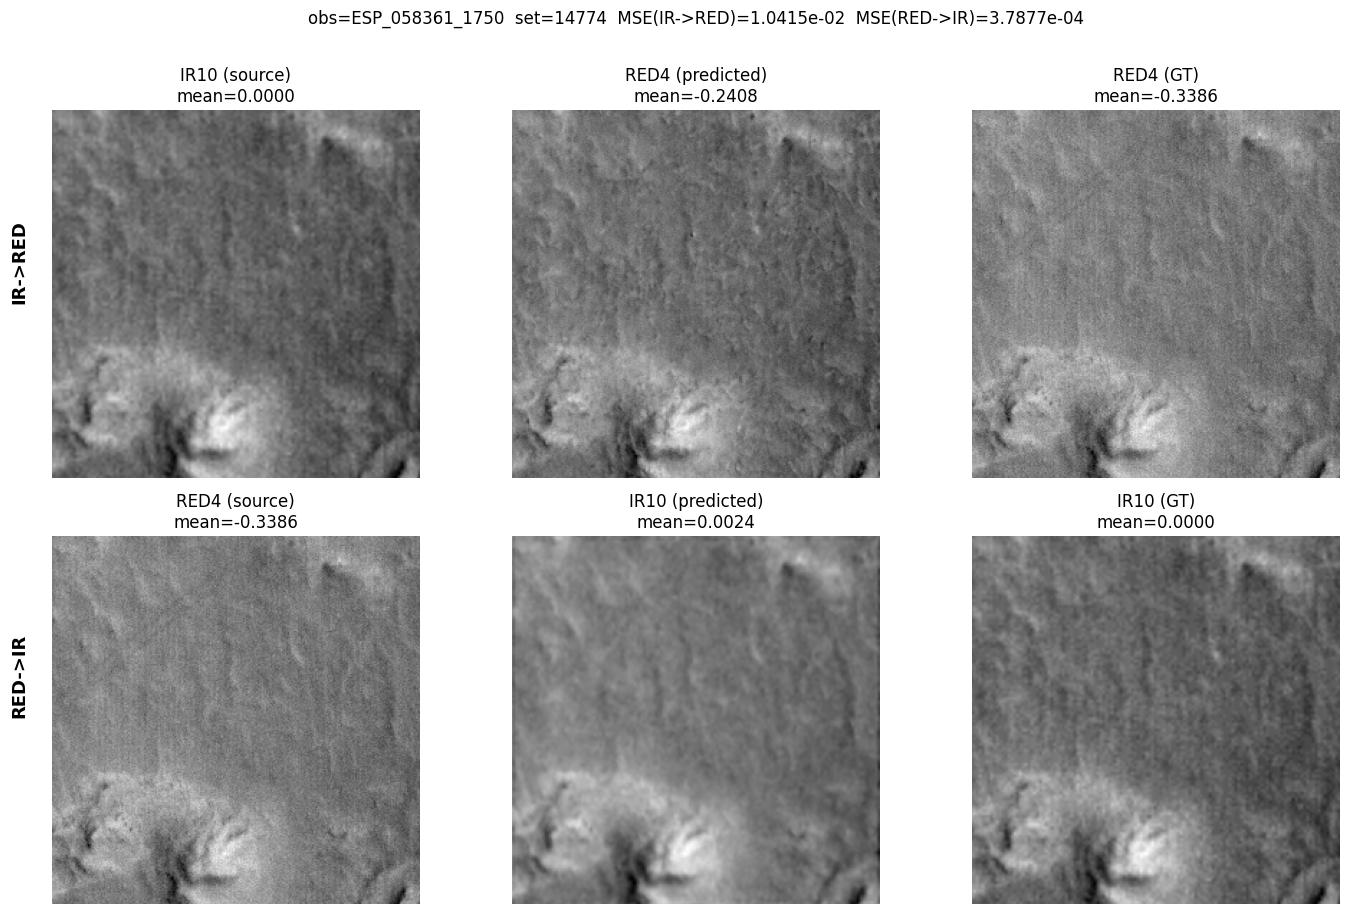

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(14, 9))

# Row 0: IR10 -> RED4
axs[0, 0].imshow(ir_display, cmap="gray")
axs[0, 0].set_title("IR10 (source)" + chr(10) + "mean={:.4f}".format(ir_display.mean()))
axs[0, 0].axis("off")

axs[0, 1].imshow(red_pred, cmap="gray")
axs[0, 1].set_title("RED4 (predicted)" + chr(10) + "mean={:.4f}".format(red_pred.mean()))
axs[0, 1].axis("off")

axs[0, 2].imshow(red_gt, cmap="gray")
axs[0, 2].set_title("RED4 (GT)" + chr(10) + "mean={:.4f}".format(red_gt.mean()))
axs[0, 2].axis("off")

# Row 1: RED4 -> IR10
axs[1, 0].imshow(red_display, cmap="gray")
axs[1, 0].set_title("RED4 (source)" + chr(10) + "mean={:.4f}".format(red_display.mean()))
axs[1, 0].axis("off")

axs[1, 1].imshow(ir_pred, cmap="gray")
axs[1, 1].set_title("IR10 (predicted)" + chr(10) + "mean={:.4f}".format(ir_pred.mean()))
axs[1, 1].axis("off")

axs[1, 2].imshow(ir_gt, cmap="gray")
axs[1, 2].set_title("IR10 (GT)" + chr(10) + "mean={:.4f}".format(ir_gt.mean()))
axs[1, 2].axis("off")

fig.text(0.01, 0.73, "IR->RED", va="center", rotation="vertical", fontsize=13, fontweight="bold")
fig.text(0.01, 0.27, "RED->IR", va="center", rotation="vertical", fontsize=13, fontweight="bold")

mse_d0 = ((red_pred - red_gt) ** 2).mean()
mse_d1 = ((ir_pred  - ir_gt ) ** 2).mean()
plt.suptitle(
    "obs={}  set={}  ".format(diff_sample["obs_id"], diff_sample["set_name"]) + f"{"Physical" if use_denorm else ""}" + \
    "MSE(IR->RED)={:.4e}  MSE(RED->IR)={:.4e}".format(mse_d0, mse_d1),
    y=1.01
)
plt.tight_layout()
plt.show()

## Experiment to test different values for lambdas
- Focusing on IR to RED

In [10]:
# Run inference for each lambda value with a fixed seed for fair comparison

lambdas = [a for a in range(0, 110, 10)]  # [0, 10, 20, ..., 100]
sci_predictions = {}
SEED = 42

for lam in lambdas:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    cfg = InferenceConfig(lambda_scl=float(lam), lambda_ccl=float(lam))
    with torch.no_grad():
        pred = sample(model, scheduler, ir_tensor, direction=0,
                      prior_stats=prior_red_stats, cfg_inf=cfg, device=device)
    sci_predictions[lam] = pred.squeeze().cpu().numpy()
    print(f"λ={lam:2d}  range=[{sci_predictions[lam].min():.3f}, {sci_predictions[lam].max():.3f}]  mean={sci_predictions[lam].mean():.3f}")

[init] sqrt_ab_T=0.0064  mu_target=-0.2094  x_T mean≈-0.0068
  t= 900  x range=[-5.028, 4.185]
  t= 800  x range=[-4.434, 4.370]
  t= 700  x range=[-3.971, 3.878]
  t= 600  x range=[-4.483, 5.124]
  t= 500  x range=[-4.533, 3.481]
  t= 400  x range=[-4.280, 3.715]
  t= 300  x range=[-3.767, 2.440]
  t= 200  x range=[-3.100, 1.439]
  t= 100  x range=[-2.262, 0.513]
  t=   0  x range=[-1.272, -0.724]
λ= 0  range=[-1.272, -0.724]  mean=-0.986
[init] sqrt_ab_T=0.0064  mu_target=-0.2094  x_T mean≈-0.0068
  t= 900  x range=[-5.028, 4.186]
  t= 800  x range=[-4.433, 4.374]
  t= 700  x range=[-3.966, 3.886]
  t= 600  x range=[-4.467, 5.136]
  t= 500  x range=[-4.504, 3.501]
  t= 400  x range=[-4.238, 3.750]
  t= 300  x range=[-3.709, 2.493]
  t= 200  x range=[-3.026, 1.509]
  t= 100  x range=[-2.179, 0.597]
  t=   0  x range=[-1.173, -0.631]
λ=10  range=[-1.173, -0.631]  mean=-0.897
[init] sqrt_ab_T=0.0064  mu_target=-0.2094  x_T mean≈-0.0068
  t= 900  x range=[-5.028, 4.188]
  t= 800  x range

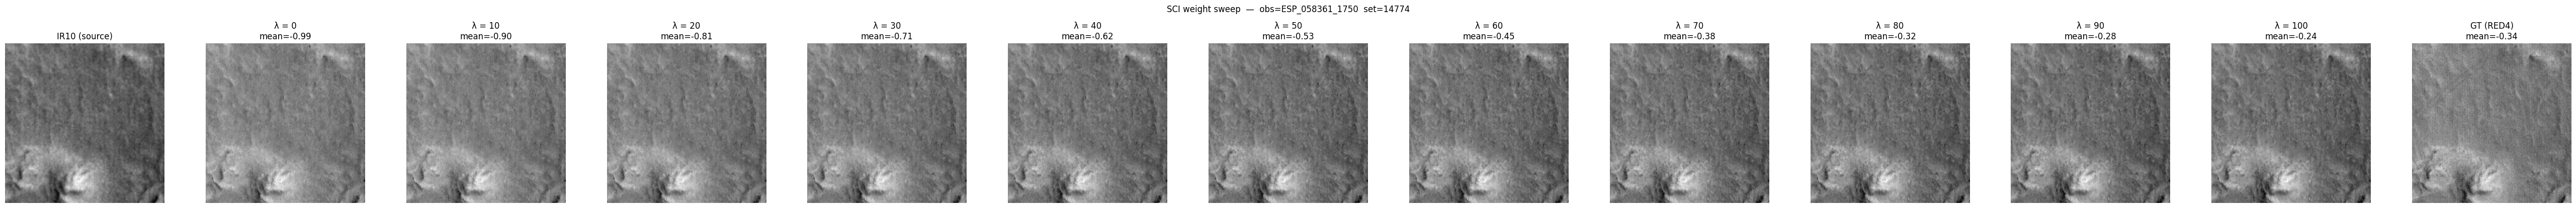

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

n_pred = len(lambdas)
fig, axs = plt.subplots(1, n_pred + 2, figsize=(4 * (n_pred + 2), 4))

axs[0].imshow(ir_display, cmap="gray")
axs[0].set_title("IR10 (source)")
axs[0].axis("off")

for i, lam in enumerate(lambdas):
    axs[i + 1].imshow(sci_predictions[lam], cmap="gray")
    mean_val = sci_predictions[lam].mean()
    axs[i + 1].set_title(f"λ = {lam}\nmean={mean_val:.2f}")
    axs[i + 1].axis("off")

axs[-1].imshow(red_gt, cmap="gray")
axs[-1].set_title(f"GT (RED4)\nmean={red_gt.mean():.2f}")
axs[-1].axis("off")

plt.suptitle(f"SCI weight sweep  —  obs={diff_sample['obs_id']}  set={diff_sample['set_name']}", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from eval import _ssim_safe

# Always derive GT from diff_sample to avoid stale-variable bugs
red_gt_sweep = diff_sample["red"].squeeze().cpu().numpy()
gt_t = torch.from_numpy(red_gt_sweep)
print(f"MSE sweep using: obs={diff_sample['obs_id']}  set={diff_sample['set_name']}  GT mean={red_gt_sweep.mean():.3f}")

# Reverse normalization
norm_stats = diff_sample["norm_stats"]
gt_t = (gt_t + norm_stats[2:3, None, None]) * norm_stats[1:2, None, None] + norm_stats[:1, None, None]

ssim_scores = {}
for lam in lambdas:
    pred_t = torch.from_numpy(sci_predictions[lam])
    pred_t = (pred_t + norm_stats[2:3, None, None]) * norm_stats[1:2, None, None] + norm_stats[:1, None, None]
    dr = (pred_t.max() - pred_t.min()).clamp(min=0.01).item()
    ssim_scores[lam] = _ssim_safe(pred_t.squeeze().cpu().numpy(), gt_t.squeeze().cpu().numpy())
    print(f"λ={lam:2d}  SSIM={ssim_scores[lam]:.4f}")

best_lam = max(ssim_scores, key=ssim_scores.get)
print(f"\nBest λ = {best_lam}  (SSIM={ssim_scores[best_lam]:.4f})")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([str(l) for l in lambdas], list(ssim_scores.values()), color="steelblue")
bars[lambdas.index(best_lam)].set_color("tomato")
ax.set_xlabel("λ (lambda_scl = lambda_ccl)")
ax.set_ylabel("SSIM vs Ground Truth")
ax.set_title("SCI weight sweep — SSIM to GT")
for bar, val in zip(bars, ssim_scores.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

MSE sweep using: obs=ESP_058361_1750  set=14774  GT mean=-0.339


TypeError: _ssim_safe() missing 1 required positional argument: 'data_range'